In [1]:
# === STEP 1: Segment and Save from Unsegmented CSVs ===
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [2]:
# CONFIG
source_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/interpolated-denoised signals (csv, Hermite)'  # folder of full-length CSVs
label_file = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/ctu_df.csv'           # patient ID to target mapping
segment_length = 1200
max_segments = 14
output_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset\Dataset 1 - CTU CHB/1D-CNN'  # segmented output

In [ ]:
# Load label dictionary
"""
label_df = pd.read_csv(label_file)
label_df['ID'] = label_df['ID'].astype(str)
label_dict = dict(zip(label_df['ID'], label_df['target']))
"""

In [ ]:
# Create output folders
"""
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'class_0'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'class_1'), exist_ok=True)
"""

In [ ]:
# === Segment and Save CSVs by Class ===
"""
for filename in os.listdir(source_dir):
    if filename.endswith('.csv'):
        patient_id = filename.split('.')[0]
        if patient_id not in label_dict:
            continue

        df = pd.read_csv(os.path.join(source_dir, filename))
        if 'FHR_denoised' not in df.columns:
            continue

        signal = df['FHR_denoised'].values
        total_samples = len(signal)
        num_segments = min(max_segments, total_samples // segment_length)

        for i in range(num_segments):
            segment = signal[i * segment_length : (i + 1) * segment_length]
            if len(segment) == segment_length:
                min_val = np.min(segment)
                max_val = np.max(segment)
                if max_val - min_val == 0:
                    continue
                segment = (segment - min_val) / (max_val - min_val)
                segment_df = pd.DataFrame({'FHR_denoised': segment})
                label = label_dict[patient_id]
                class_folder = os.path.join(output_dir, f'class_{label}')
                segment_filename = f'{patient_id}_segment_{i+1}.csv'
                segment_df.to_csv(os.path.join(class_folder, segment_filename), index=False)

print("✅ All segments saved by class into folders.")
"""

In [3]:
# === STEP 2: Load and Preprocess Segmented Files ===
segmented_dir = output_dir
X = []

y = []

for class_label in ['class_0', 'class_1']:
    label = int(class_label.split('_')[1])
    class_path = os.path.join(segmented_dir, class_label)
    for file in os.listdir(class_path):
        if file.endswith('.csv'):
            file_path = os.path.join(class_path, file)
            df = pd.read_csv(file_path)
            if 'FHR_denoised' not in df.columns:
                continue
            signal = df['FHR_denoised'].values
            if len(signal) == segment_length:
                min_val = np.min(signal)
                max_val = np.max(signal)
                if max_val - min_val == 0:
                    continue
                norm_signal = (signal - min_val) / (max_val - min_val)
                X.append(norm_signal.reshape(segment_length, 1))
                y.append(label)

X = np.array(X)
y = np.array(y)


In [4]:
# === Train-Test Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# === STEP 3: Build 1D-CNN ===
model = Sequential([
    Conv1D(32, kernel_size=7, activation='relu', input_shape=(segment_length, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1194, 32)          256       
                                                                 
 batch_normalization (BatchN  (None, 1194, 32)         128       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 597, 32)          0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 593, 64)           10304     
                                                                 
 batch_normalization_1 (Batc  (None, 593, 64)          256       
 hNormalization)                                                 
                                                        

In [5]:
# === STEP 4: Train ===
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

Epoch 1/50
184/184 [==============================] - 16s 78ms/step - loss: 0.9276 - accuracy: 0.7597 - val_loss: 2.8303 - val_accuracy: 0.8098
Epoch 2/50
184/184 [==============================] - 14s 75ms/step - loss: 0.5239 - accuracy: 0.8069 - val_loss: 2.1961 - val_accuracy: 0.8098
Epoch 3/50
184/184 [==============================] - 13s 73ms/step - loss: 0.5018 - accuracy: 0.8071 - val_loss: 0.7245 - val_accuracy: 0.7242
Epoch 4/50
184/184 [==============================] - 13s 73ms/step - loss: 0.4856 - accuracy: 0.8086 - val_loss: 0.7603 - val_accuracy: 0.8057
Epoch 5/50
184/184 [==============================] - 13s 73ms/step - loss: 0.4751 - accuracy: 0.8086 - val_loss: 0.5203 - val_accuracy: 0.8098
Epoch 6/50
184/184 [==============================] - 13s 72ms/step - loss: 0.4422 - accuracy: 0.8129 - val_loss: 0.8345 - val_accuracy: 0.7486
Epoch 7/50
184/184 [==============================] - 13s 73ms/step - loss: 0.4284 - accuracy: 0.8141 - val_loss: 0.5199 - val_accuracy:

In [6]:
# === STEP 5: Evaluate ===
y_scores = model.predict(X_val).flatten()
y_pred = (y_scores > 0.3).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred, digits=4))

46/46 [==============================] - 1s 15ms/step

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.2348    0.0964    0.1367       280
           1     0.8136    0.9262    0.8662      1192

    accuracy                         0.7683      1472
   macro avg     0.5242    0.5113    0.5015      1472
weighted avg     0.7035    0.7683    0.7275      1472



In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
# === STEP 6: Confusion Matrix ===
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Confusion Matrix:
[[  27  253]
 [  88 1104]]


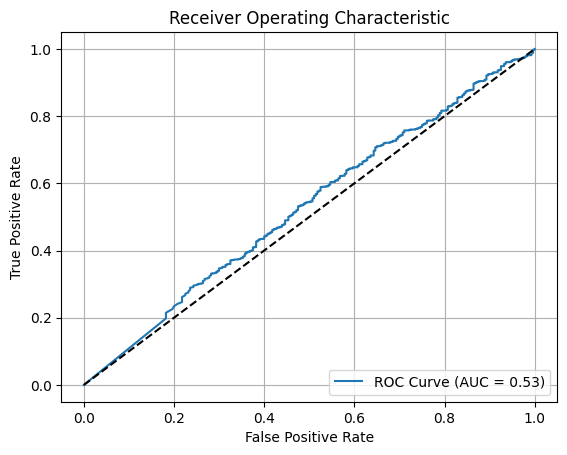

In [8]:
import matplotlib.pyplot as plt
# === STEP 7: ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

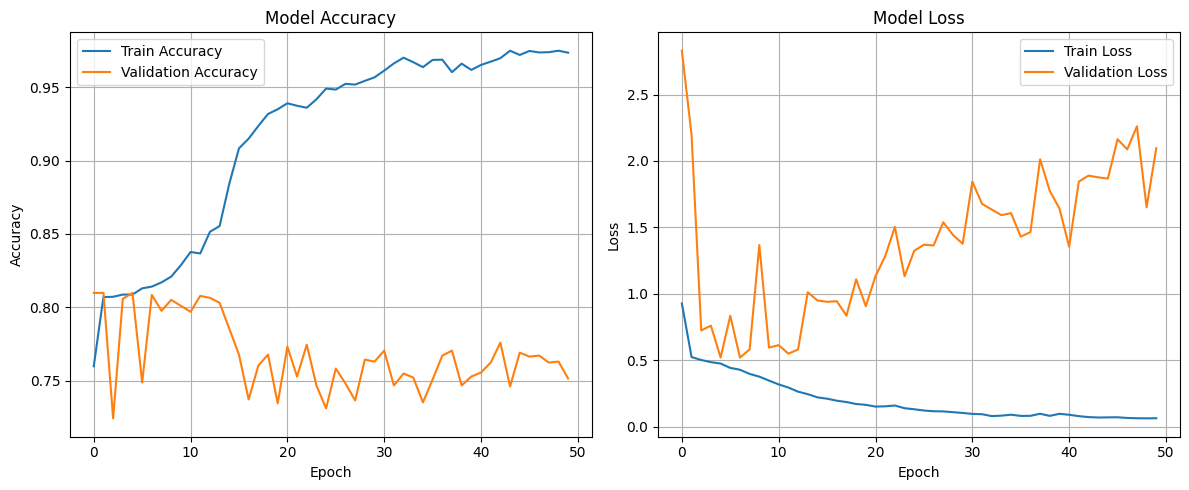

In [9]:
# === STEP 8: Accuracy and Loss Curves ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()